In [1]:
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import matplotlib.patches as mpatches
import pandas as pd
import datetime
import numpy as np
import re
import cartopy.crs as ccrs
import cartopy
import cartopy.geodesic as cgeodesic
import xarray as xr
import warnings
from scipy.stats import linregress
from scipy.stats import gaussian_kde

In [2]:
def read_tracks(filename=None, var_names=None):
    regex_clean = re.compile(r'&')
    
    with open(filename, 'r') as file:
        lines = file.readlines()

    assert len(lines) > 0, "File does not exist or is empty"

    i_start = [i for i, line in enumerate(lines) if line.startswith('TRACK_ID')]
    n_tracks = len(i_start)

    tracks = []
    for ii in range(n_tracks):
        start_ = i_start[ii] + 2
        n_points = int(lines[i_start[ii] + 1].split()[1])
        track_lines = lines[start_:start_ + n_points]

        track_lines = [regex_clean.sub('', line).split() for line in track_lines]
        data = np.array(track_lines, dtype=float)
        data[data == 1e25] = np.nan

        columns = ['ID', 'start_time', 'median_time', 'name']
        split_line = lines[i_start[ii]].split()
        
        id_id = split_line[1] if len(split_line) > 1 else 'unknown'
        start_time = split_line[3] if len(split_line) > 3 else 'unknown'
        median_time = split_line[5] if len(split_line) > 5 else 'unknown'
        name_storm = split_line[9] if len(split_line) > 9 else 'unknown'
        
        df = pd.DataFrame(data, columns=var_names[:data.shape[1]])
        df['ID'] = id_id
        df['start_time'] = start_time
        df['median_time'] = median_time
        df['name'] = name_storm
        
        tracks.append(df)

    result = pd.concat(tracks, ignore_index=True)
    result['ID'] = result['ID'].astype('category')

    return result

In [3]:
def calc_speed_dir(data, freq):
    geodesic = cgeodesic.Geodesic()

    distances = []
    speeds = []
    bearings = []
    indices = []

    for name, group in data.groupby('ID'):
        if len(group) < 2:
            continue

        for i in range(len(group) - 1):
            out = geodesic.inverse(
                [group['lon_vor'].iloc[i], group['lat_vor'].iloc[i]],
                [group['lon_vor'].iloc[i+1], group['lat_vor'].iloc[i+1]])

            distance = out[0, 0] * 1e-3  # Convert meters to kilometers
            speed = out[0, 0] / (freq * 3600)  # Calculate speed
            bearing = out[0, 1]  # Azimuth bearing

            distances.append(distance)
            speeds.append(speed)
            bearings.append(bearing)
            indices.append(group.index[i])

    data.loc[indices, 'distance'] = distances
    data.loc[indices, 'speed'] = speeds
    data.loc[indices, 'bearing'] = bearings

    return data

def adjust_bearing(bearing):
    if -180 <= bearing < 0:
        return bearing + 360
    return bearing

## Historical Projection Comparison

In [4]:
trx_hist = pd.DataFrame()

for i in range(1970, 2005):
    file_path = f'Track/ERA5_VOR850_1hr_oct-mar{i}{i+1}_NORTHSEA_minwindspeed25_longlive.csv'
    trx_data = pd.read_csv(file_path)
    trx_hist = pd.concat([trx_hist, trx_data], ignore_index=True)
    
trx_hist.head()

,Unnamed: 0,date,lon_vor,lat_vor,var_vor,lon_mslp,lat_mslp,var_mslp,lon_wind,lat_wind,var_wind,lon_prec,lat_prec,var_prec,ID,start_time,median_time,name,season,duration
0,0,1970-10-01 10:00:00,341.063995,57.650780,4.482560,NaN,NaN,998.2866,338.6250,55.22246,34.27062,329.9062,58.59482,20.44475,162,1970-10-01 10:00:00,NaN,NaN,1970-1971,3 days 19:00:00
1,1,1970-10-01 11:00:00,342.595428,57.787827,4.871108,NaN,NaN,998.0967,340.3125,54.94143,33.40303,331.3125,58.31379,20.23147,162,1970-10-01 10:00:00,NaN,NaN,1970-1971,3 days 19:00:00
2,2,1970-10-01 12:00:00,344.497528,57.996307,5.227600,NaN,NaN,995.9141,342.8438,54.94143,33.11104,333.2812,58.03276,19.36680,162,1970-10-01 10:00:00,NaN,NaN,1970-1971,3 days 19:00:00
3,3,1970-10-01 13:00:00,346.339630,58.208485,5.612302,NaN,NaN,994.4285,344.5312,54.94143,33.16609,335.5312,58.03276,18.79157,162,1970-10-01 10:00:00,NaN,NaN,1970-1971,3 days 19:00:00
4,4,1970-10-01 14:00:00,348.057220,58.379707,6.006207,NaN,NaN,992.5260,345.9375,55.50349,32.91948,336.9375,58.03276,19.08017,162,1970-10-01 10:00:00,NaN,NaN,1970-1971,3 days 19:00:00


In [4]:
trx_hist['date'] = pd.to_datetime(trx_hist['date'])
trx_hist['month'] = trx_hist['date'].dt.month
trx_hist_djf = trx_hist[trx_hist['month'].isin([12, 1, 2])]
trx_hist_djf

,Unnamed: 0,date,lon_vor,lat_vor,var_vor,lon_mslp,lat_mslp,var_mslp,lon_wind,lat_wind,...,lon_prec,lat_prec,var_prec,ID,start_time,median_time,name,season,duration,month
814,814,1971-01-22 16:00:00,342.745605,53.646374,7.281176,NaN,NaN,964.4221,348.46880,53.25525,...,336.37500,50.44494,18.99430,18065,1971-01-22 16:00:00,NaN,NaN,1970-1971,2 days 09:00:00,1
815,815,1971-01-22 17:00:00,343.766541,53.834408,7.781779,NaN,NaN,964.3932,338.90620,49.03979,...,348.18750,54.37937,19.52383,18065,1971-01-22 16:00:00,NaN,NaN,1970-1971,2 days 09:00:00,1
816,816,1971-01-22 18:00:00,344.204742,54.088921,8.501598,NaN,NaN,963.7099,347.90620,54.66040,...,334.96880,51.85009,19.31870,18065,1971-01-22 16:00:00,NaN,NaN,1970-1971,2 days 09:00:00,1
817,817,1971-01-22 19:00:00,344.474121,54.323574,9.280985,NaN,NaN,962.6285,339.46880,49.32082,...,335.53120,51.85009,19.41443,18065,1971-01-22 16:00:00,NaN,NaN,1970-1971,2 days 09:00:00,1
818,818,1971-01-22 20:00:00,344.652924,54.549656,9.925208,NaN,NaN,961.7756,349.31250,54.37937,...,336.93750,52.13113,19.55278,18065,1971-01-22 16:00:00,NaN,NaN,1970-1971,2 days 09:00:00,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58142,1502,2005-02-15 01:00:00,13.913796,52.336872,4.922681,14.79564,52.98662,998.9910,13.21875,54.66040,...,7.87500,57.18967,14.37529,20700,2005-02-11 17:00:00,NaN,NaN,2004-2005,3 days 12:00:00,2
58143,1503,2005-02-15 02:00:00,13.309422,52.050167,4.665063,14.47863,52.80817,999.7564,13.50000,54.66040,...,8.15625,57.18967,13.83645,20700,2005-02-11 17:00:00,NaN,NaN,2004-2005,3 days 12:00:00,2
58144,1504,2005-02-15 03:00:00,12.646689,51.793213,4.391312,14.33999,52.62321,1000.7220,13.50000,54.37937,...,6.75000,53.81731,13.21989,20700,2005-02-11 17:00:00,NaN,NaN,2004-2005,3 days 12:00:00,2
58145,1505,2005-02-15 04:00:00,11.880169,51.450470,4.029134,13.95690,52.38875,1001.7740,13.21875,54.09834,...,3.65625,53.53628,13.09413,20700,2005-02-11 17:00:00,NaN,NaN,2004-2005,3 days 12:00:00,2


In [5]:
trx_hist_djf = calc_speed_dir(trx_hist_djf, 1)
trx_hist_djf['bearing'] = trx_hist['bearing'].apply(adjust_bearing)
trx_hist_djf['uniq_id'] = list(zip(trx_hist_djf['ID'], trx_hist_djf['season']))
trx_hist_djf['lon_vor'] = ((trx_hist_djf['lon_vor'] + 180) % 360) - 180
trx_hist_djf['speed'] = pd.to_numeric(trx_hist_djf['speed'], errors='coerce')
trx_hist_djf['speed'].fillna(trx_hist_djf['speed'].mean(), inplace=True)
print('all storm:', trx_hist_djf['ID'].nunique())
print('Number of unique storms (ID and season):', trx_hist_djf['uniq_id'].nunique())

/tmp/ipykernel_684/840448504.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[indices, 'distance'] = distances
/tmp/ipykernel_684/840448504.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[indices, 'speed'] = speeds
/tmp/ipykernel_684/840448504.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/us

In [7]:
def storm_direction(group):
    westerly_count = sum((group['bearing'] >= 30) & (group['bearing'] <= 120))
    northerly_count = sum((group['bearing'] > 120) & (group['bearing'] <= 240))
    if northerly_count > westerly_count:
        return 'Northerly'
    else:
        return 'Westerly'
    
storm_filter = trx_hist_djf[(trx_hist_djf['lat_vor'] >= 50) & (trx_hist_djf['lat_vor'] <= 60) &
                 (trx_hist_djf['lon_vor'] >= -10) & (trx_hist_djf['lon_vor'] <= 10)]

# Apply the function to each storm ID group
category = storm_filter.groupby('uniq_id').apply(storm_direction).reset_index()
category.columns = ['uniq_id', 'category']

# Merge the category information back to the original DataFrame
trx_hist_djf = trx_hist_djf.merge(category, on='uniq_id', how='left')
trx_hist_djf

In [26]:
freq_hist_djf = trx_hist_djf.drop_duplicates(subset=['uniq_id'])
year_north_hist = freq_hist_djf['season'].value_counts().sort_index()
year_north_hist = year_north_hist.values.tolist()

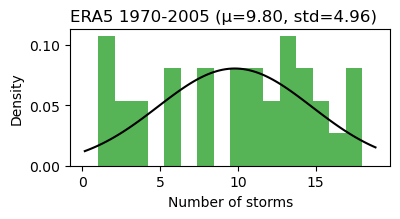

In [40]:
from scipy.stats import norm
fig, axs = plt.subplots(1, 1, figsize=(4.1, 2.3))
mu, std = norm.fit(year_north_hist)
axs.hist(year_north_hist, bins=16, density=True, alpha=0.8, color='tab:green')
xmin, xmax = axs.get_xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)
axs.plot(x, p, 'k', linewidth=1.5)
title = f"ERA5 1970-2005 (μ={mu:.2f}, std={std:.2f})"
axs.set_title(title, loc='left')
axs.set_xlabel('Number of storms')
axs.set_ylabel('Density')

plt.tight_layout()
plt.show()

## All North Sea Storm Track 1982-2022

In [4]:
trx_all = pd.DataFrame()

for i in range(1982, 2022):
    #file_path = f'Track/ERA5_VOR850_1hr_oct-mar{i}{i+1}_NORTHSEA_minwindspeed25.csv'
    file_path = f'Track/ERA5_VOR850_1hr_oct-mar{i}{i+1}_NORTHSEA_minwindspeed25_longlive.csv'
    trx_data = pd.read_csv(file_path)
    trx_all = pd.concat([trx_all, trx_data], ignore_index=True)

trx_all = calc_speed_dir(trx_all, 1)
trx_all['bearing'] = trx_all['bearing'].apply(adjust_bearing)
trx_all['uniq_id'] = list(zip(trx_all['ID'], trx_all['season']))
print('Number of unique storms (ID and season):', trx_all['uniq_id'].nunique())

trx_all['lon_vor'] = ((trx_all['lon_vor'] + 180) % 360) - 180
trx_all['speed'] = pd.to_numeric(trx_all['speed'], errors='coerce')
trx_all['speed'].fillna(trx_all['speed'].mean(), inplace=True)

trx_all.head()

,Unnamed: 0,date,lon_vor,lat_vor,var_vor,lon_mslp,lat_mslp,var_mslp,lon_wind,lat_wind,var_wind,lon_prec,lat_prec,var_prec,ID,start_time,median_time,name,season,duration
0,0,1982-10-19 13:00:00,1.534199,58.076061,2.661184,NaN,NaN,1003.516,4.21875,62.52924,40.63476,3.37500,61.96718,20.57130,2641,1982-10-19 13:00:00,NaN,NaN,1982-1983,5 days 15:00:00
1,1,1982-10-19 14:00:00,2.616141,57.525417,2.881066,NaN,NaN,1005.743,4.78125,62.24821,39.33882,3.93750,62.81027,20.07453,2641,1982-10-19 13:00:00,NaN,NaN,1982-1983,5 days 15:00:00
2,2,1982-10-19 15:00:00,3.408462,57.387611,3.076569,NaN,NaN,1006.686,4.78125,62.52924,35.92666,4.21875,63.37233,18.02655,2641,1982-10-19 13:00:00,NaN,NaN,1982-1983,5 days 15:00:00
3,3,1982-10-19 16:00:00,3.932111,57.438416,3.175046,NaN,NaN,1006.377,5.06250,62.52924,32.58338,4.50000,61.96718,18.71960,2641,1982-10-19 13:00:00,NaN,NaN,1982-1983,5 days 15:00:00
4,4,1982-10-19 17:00:00,4.410720,57.631748,3.225164,NaN,NaN,1005.896,5.34375,62.81027,30.18725,5.06250,62.24821,17.47002,2641,1982-10-19 13:00:00,NaN,NaN,1982-1983,5 days 15:00:00


In [6]:
from scipy.stats import gaussian_kde
def calculate_pdf(data, bw_method='scott'):
    kde = gaussian_kde(data, bw_method=bw_method)
    return kde

freq_all = trx_all.drop_duplicates(subset=['uniq_id'])
all_hist = freq_all['season'].value_counts().sort_index()
all_hist = all_hist.values.tolist()

kde_trx = gaussian_kde(all_hist)
x_trx = np.linspace(0, 40, 1000)
kde_values_trx = kde_trx(x_trx)

mean_trx = np.sum(x_trx * kde_values_trx) * (x_trx[1] - x_trx[0])
variance_trx = np.sum((x_trx - mean_trx)**2 * kde_values_trx) * (x_trx[1] - x_trx[0])
std_trx = np.sqrt(variance_trx)

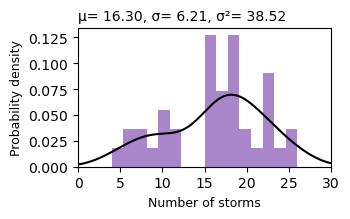

In [7]:
fig, axs = plt.subplots(1, 1, figsize=(3.6, 2.3))
axs.set_xlim(0,30)
axs.set_yticks(np.arange(0,0.175,0.025))
axs.hist(all_hist, bins=16, density=True, alpha=0.8, color='tab:purple')
axs.plot(x_trx, kde_values_trx, label='KDE', color='black')
axs.set_title(f'μ= {mean_trx:.2f}, σ= {std_trx:.2f}, σ²= {variance_trx:.2f}', fontsize=10, loc='left')
axs.set_xlabel('Number of storms', fontsize=9)
axs.set_ylabel('Probability density', fontsize=9)
plt.tight_layout()
plt.show()

In [83]:
trx_all_prev = pd.DataFrame()

for i in range(1982, 2022):
    #file_path = f'Track/ERA5_VOR850_1hr_oct-mar{i}{i+1}_NORTHSEA_minwindspeed25.csv'
    file_path = f'Track/ERA5_VOR850_1hr_oct-mar{i}{i+1}_NORTHSEA_minwindspeed25.csv'
    trx_data_prev = pd.read_csv(file_path)
    trx_all_prev = pd.concat([trx_all_prev, trx_data_prev], ignore_index=True)

trx_all_prev = calc_speed_dir(trx_all_prev, 1)
trx_all_prev['bearing'] = trx_all_prev['bearing'].apply(adjust_bearing)
trx_all_prev['uniq_id'] = list(zip(trx_all_prev['ID'], trx_all_prev['season']))
print('all storm:', trx_all_prev['ID'].nunique())
print('Number of unique storms (ID and season):', trx_all_prev['uniq_id'].nunique())

trx_all_prev['lon_vor'] = ((trx_all_prev['lon_vor'] + 180) % 360) - 180
trx_all_prev['speed'] = pd.to_numeric(trx_all_prev['speed'], errors='coerce')
trx_all_prev['speed'].fillna(trx_all_prev['speed'].mean(), inplace=True)
trx_all_prev.head()

,Unnamed: 0,date,lon_vor,lat_vor,var_vor,lon_mslp,lat_mslp,var_mslp,lon_wind,lat_wind,var_wind,lon_prec,lat_prec,var_prec,ID,start_time,median_time,name,season
0,25765,1982-10-19 13:00:00,1.534199,58.076061,2.661184,NaN,NaN,1003.516,4.21875,62.52924,40.63476,3.37500,61.96718,20.57130,2641,1982-10-19 13:00:00,NaN,unknown,1982-1983
1,25766,1982-10-19 14:00:00,2.616141,57.525417,2.881066,NaN,NaN,1005.743,4.78125,62.24821,39.33882,3.93750,62.81027,20.07453,2641,1982-10-19 13:00:00,NaN,unknown,1982-1983
2,25767,1982-10-19 15:00:00,3.408462,57.387611,3.076569,NaN,NaN,1006.686,4.78125,62.52924,35.92666,4.21875,63.37233,18.02655,2641,1982-10-19 13:00:00,NaN,unknown,1982-1983
3,25768,1982-10-19 16:00:00,3.932111,57.438416,3.175046,NaN,NaN,1006.377,5.06250,62.52924,32.58338,4.50000,61.96718,18.71960,2641,1982-10-19 13:00:00,NaN,unknown,1982-1983
4,25769,1982-10-19 17:00:00,4.410720,57.631748,3.225164,NaN,NaN,1005.896,5.34375,62.81027,30.18725,5.06250,62.24821,17.47002,2641,1982-10-19 13:00:00,NaN,unknown,1982-1983


In [102]:
m = ~trx_all_prev['uniq_id'].isin(trx_all['uniq_id'])
trx_residu = trx_all_prev[m]
trx_residu = trx_all_prev.loc[trx_all_prev.index.difference(trx_all.index)]
trx_residu = calc_speed_dir(trx_residu, 1)
trx_residu['bearing'] = trx_residu['bearing'].apply(adjust_bearing)
trx_residu['uniq_id'] = list(zip(trx_residu['ID'], trx_residu['season']))
print('all storm:', trx_residu['ID'].nunique())
print('Number of unique storms (ID and season):', trx_residu['uniq_id'].nunique())

trx_residu['lon_vor'] = ((trx_residu['lon_vor'] + 180) % 360) - 180
trx_residu['speed'] = pd.to_numeric(trx_residu['speed'], errors='coerce')
trx_residu['speed'].fillna(trx_residu['speed'].mean(), inplace=True)
trx_residu.head()

all storm: 333
Number of unique storms (ID and season): 336


In [51]:
import matplotlib.colors as mcolors
def plot_density (data, var, fig_title):
    lons = data[f'lon_{var}'].apply(lambda lon: ((lon + 180) % 360) - 180)
    lats = data[f'lat_{var}'].apply(lambda lat: np.clip(lat, -90, 90))
    
    datacrs = ccrs.PlateCarree()
    mapcrs = ccrs.Orthographic(central_longitude=0, central_latitude=55)
    
    fig, ax = plt.subplots(figsize=(8., 7.), subplot_kw={'projection': mapcrs})
    ax.set_extent([-120, 100, 10, 90], crs=ccrs.PlateCarree())
    #ax.set_extent([-180, 28, 25, 90], crs=ccrs.PlateCarree())
    ax.add_feature(cartopy.feature.COASTLINE, zorder=17, linewidth=0.8)
    gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
    gl.top_labels = False
    gl.right_labels = False
    
    lon = np.linspace(-180, 180, 100)
    lat = np.linspace(-90, 90, 100)
    lon_grid, lat_grid = np.meshgrid(lon, lat)
    grid_coords = np.vstack([lon_grid.ravel(), lat_grid.ravel()])
    
    xy = np.vstack([lons, lats])
    kde = gaussian_kde(xy)
    z = kde(grid_coords).reshape(lon_grid.shape) * 10000
    colorvim_levels = np.arange(0, 12, 1)
    norm = mcolors.Normalize(vmin=0.5, vmax=12)
    cmap_col = plt.cm.viridis_r
    #z = np.ma.masked_less_equal(z, 0.5)
    z[z = 0] = np.nan
    sc = ax.contourf(lon_grid, lat_grid, z, norm=norm, levels=colorvim_levels, vmin=1, cmap=cmap_col, extend='max', 
                     alpha=0.8, zorder=16, transform=datacrs)
    ax.scatter(lons, lats, c=kde(xy), s=7, cmap='viridis_r', edgecolor='none', alpha=0.5, transform=datacrs)
    cs = ax.contour(lon_grid, lat_grid, z, levels=colorvim_levels, colors='grey', linewidths=0.3, zorder=40, transform=datacrs)
    plt.clabel(cs, inline=1, fontsize=5, fmt='%.0f')
    ax.add_patch(mpatches.Rectangle(xy=[-10, 50], width=20, height=10, zorder=18, facecolor='none', 
                                 edgecolor='red', transform=datacrs))
    
    cbar = plt.colorbar(sc, norm=norm, ax=ax, orientation='horizontal', pad=0.06, aspect=40)
    cbar.set_ticks([0, 2, 4, 6, 8, 10])
    cbar.set_ticklabels([0, 2, 4, 6, 8, 10])
    cbar.set_label('Density (× 10⁻⁴)')
    
    #cbar = plt.colorbar(sc, ax=ax, orientation='horizontal', pad=0.05, aspect=50)
    #cbar.set_label('Density')
    #ax.set_title(fig_title)
    #plt.savefig('storm_19792021_density.png', dpi=300)
    plt.show()

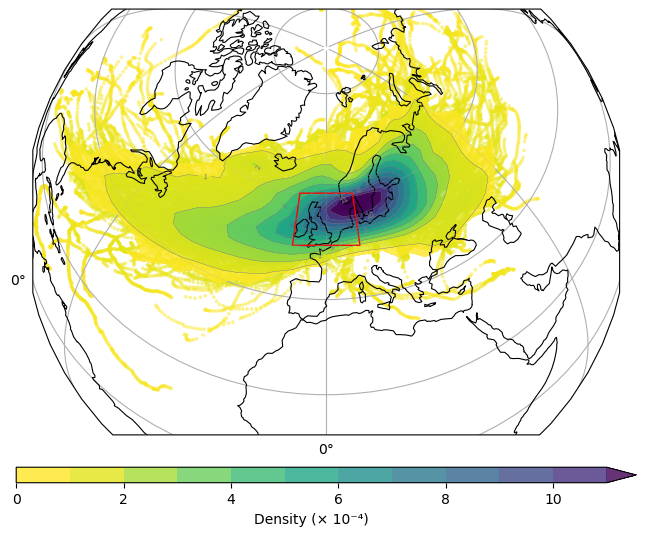

In [52]:
plot_density(trx_all, 'vor', 'North Sea Storms (1982-2022) Density')

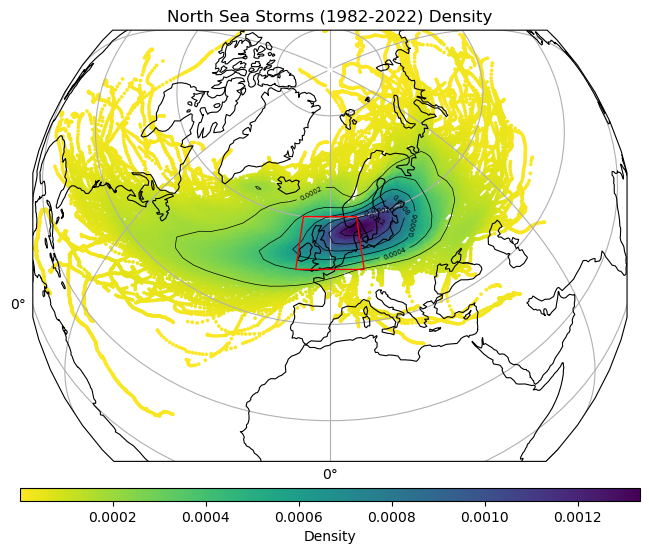

In [16]:
plot_density(trx_all, 'vor', 'North Sea Storms (1982-2022) Density')

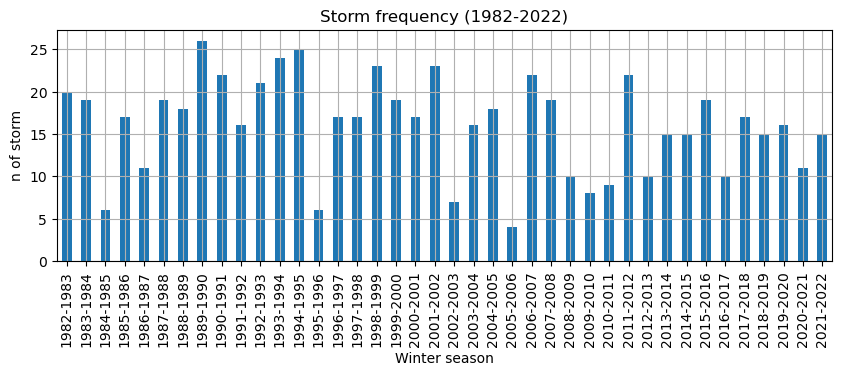

In [49]:
filtered_storm = trx_all.drop_duplicates(subset=['uniq_id'])
season_counts = filtered_storm['season'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(10., 3.))
season_counts.plot(kind='bar', color='tab:blue')
plt.title('Storm frequency (1982-2022)')
plt.xlabel('Winter season')
plt.ylabel('n of storm')
plt.xticks(rotation=90)
plt.grid(True)
plt.show()

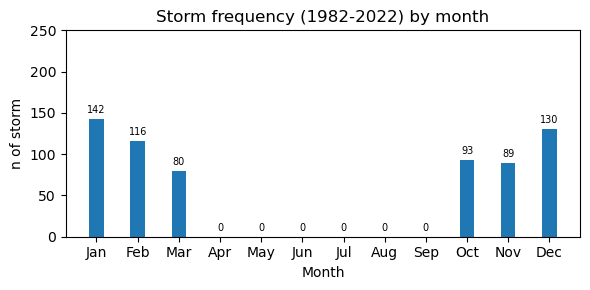

In [233]:
sta_month = trx_all['start_time'].dropna().unique()
sta_month = pd.to_datetime(sta_month)
sta_months = pd.Series([date.month for date in sta_month])
sta_counts = sta_months.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6., 3.))
months = range(1, 13)
bar_width = 0.35
sta_positions = [x - bar_width/2 for x in months]

bars = ax.bar(months, sta_counts.reindex(months, fill_value=0), width=bar_width, label='Start Time', color='tab:blue')

ax.set_title('Storm frequency (1982-2022) by month')
ax.set_xlabel('Month')
ax.set_ylabel('n of storm')
ax.set_ylim(0, 250)
ax.set_xticks(months)
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
for bar in bars:
   height = bar.get_height()
   ax.annotate(f'{height}', xy=(bar.get_x() + bar.get_width() / 2, height), xytext=(0, 3),
   textcoords="offset points", ha='center', va='bottom', size=7)

#ax.legend(loc='upper right')

#plt.grid(True)
plt.tight_layout()
plt.show()

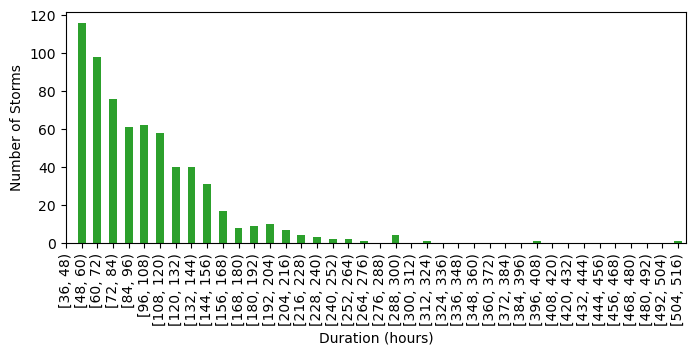

In [28]:
trx_all['duration_timedelta'] = pd.to_timedelta(trx_all['duration'])
trx_all['duration_hours'] = trx_all['duration_timedelta'].dt.total_seconds() / 3600

filtered_storm = trx_all.drop_duplicates(subset=['uniq_id'])

bin_edges = list(range(0, int(filtered_storm['duration_hours'].max()) + 12, 12))
binned_durations = pd.cut(filtered_storm['duration_hours'], bins=bin_edges, right=False)

duration_count = binned_durations.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8., 3.))

duration_count.plot(kind='bar', color='tab:green', ax=ax)

plt.xlabel('Duration (hours)')
plt.ylabel('Number of Storms')
plt.xticks(rotation=90)
ax.set_xlim(3,)

plt.show()

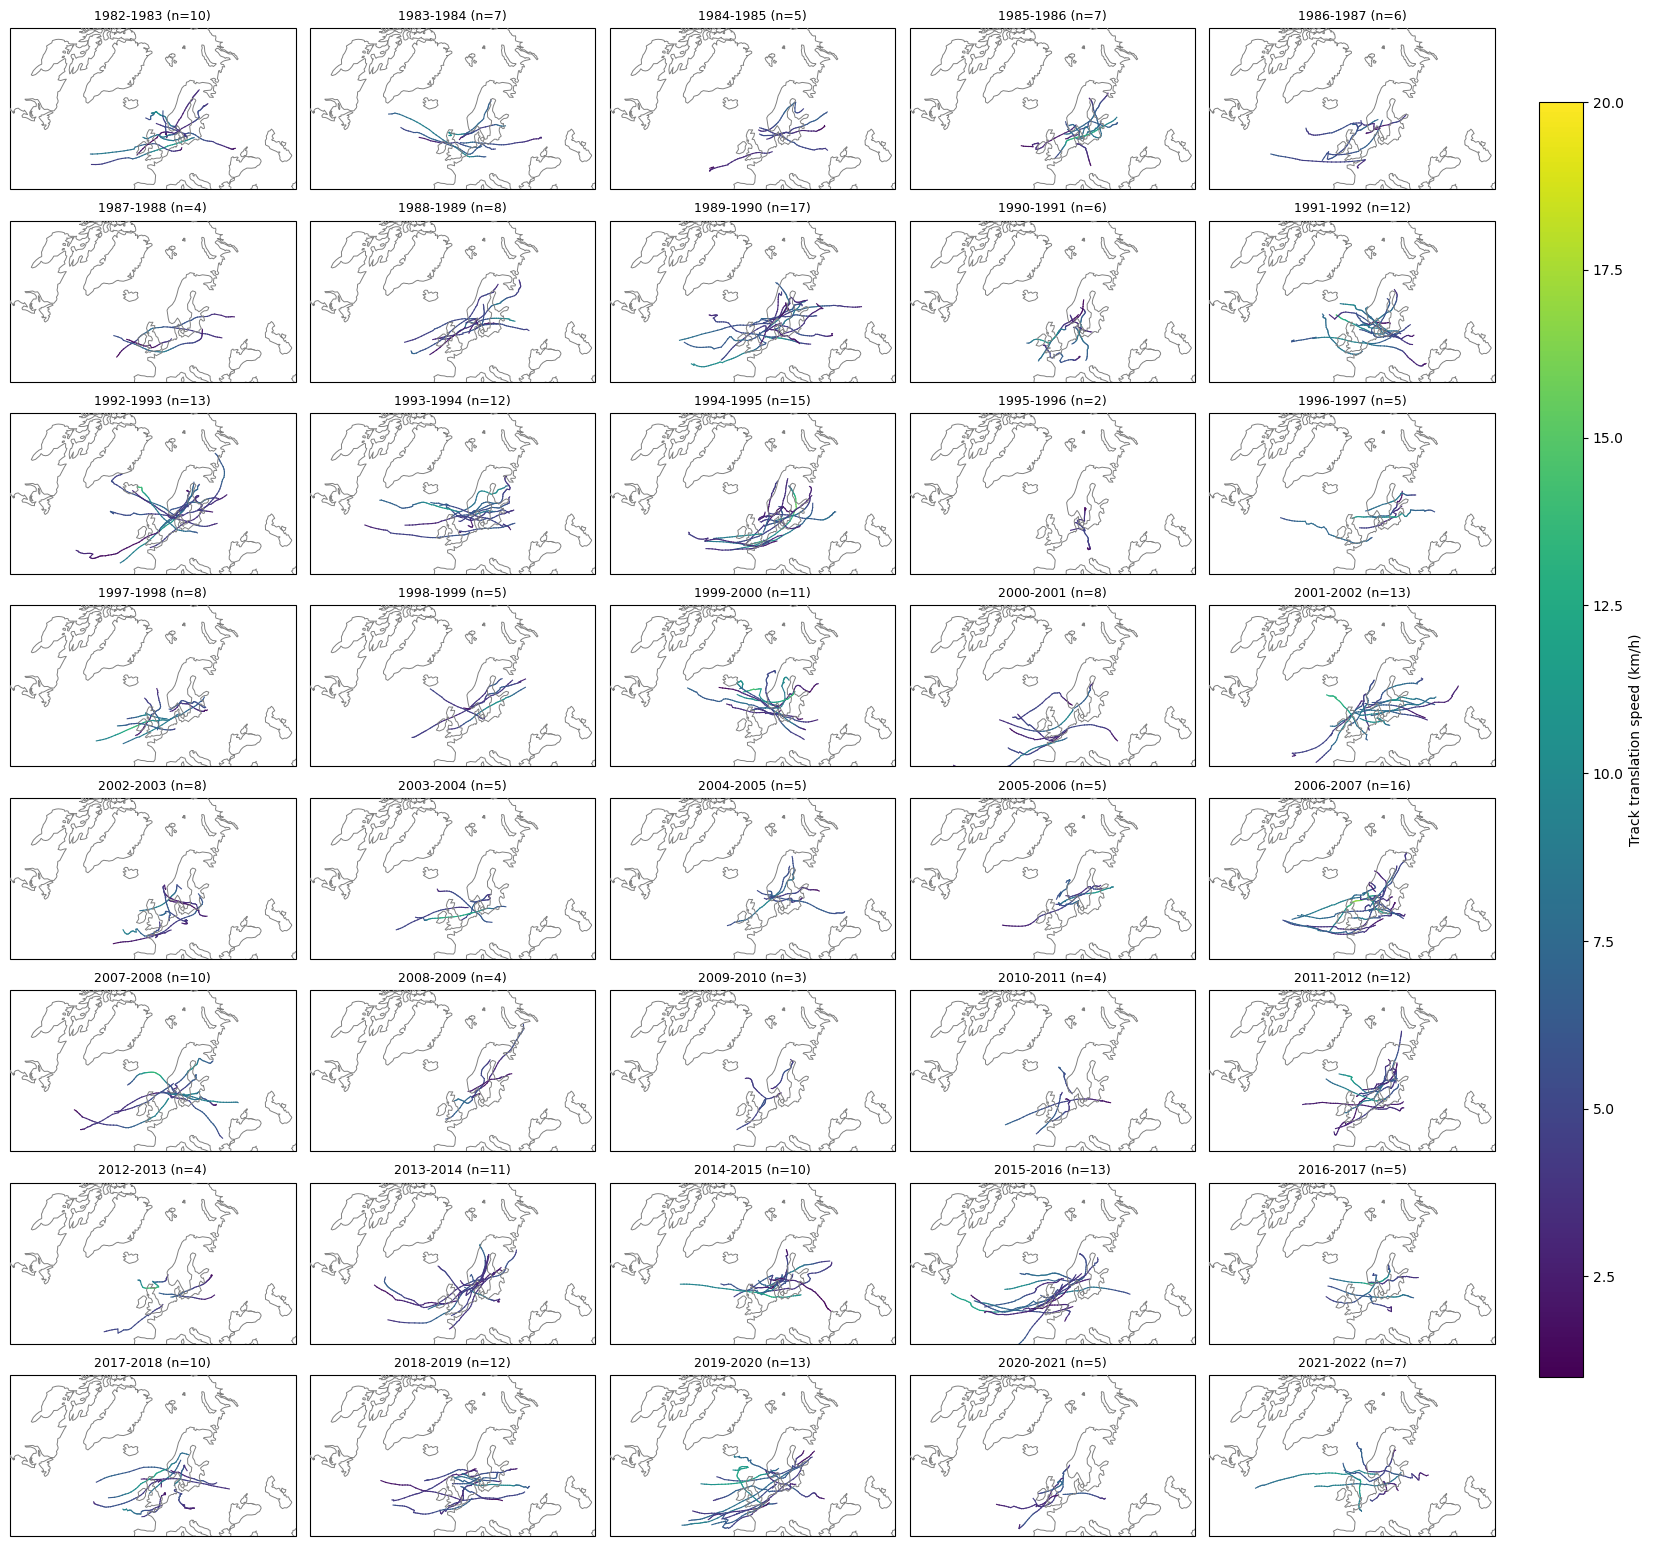

In [108]:
warnings.filterwarnings('ignore', category=pd.errors.SettingWithCopyWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

datacrs = ccrs.PlateCarree()
mapcrs = ccrs.Orthographic(central_longitude=0, central_latitude=50)
boundary = [-70, 60, 90, 40]

fig, axs = plt.subplots(8, 5, sharey=True, sharex=True, figsize=(22., 17.), subplot_kw={'projection': mapcrs})
axs = axs.ravel()

for iyear, ax in enumerate(axs):
    year = 1982 + iyear
    trx_season = trx_residu[trx_residu['season'] == f'{year}-{year+1}']
    if trx_season.empty:
        continue

    season = trx_season['season'].iloc[0]
    n_storm = trx_season['ID'].nunique()

    ax.set_extent(boundary, crs=datacrs)
    #ax.add_feature(cartopy.feature.COASTLINE, zorder=17)
    ax.coastlines(resolution='110m', zorder=17, linewidth=0.7, color='grey')

    cmap = plt.cm.viridis
    norm = Normalize(1, 20)

    points = trx_season[['lon_vor', 'lat_vor']].values
    color_values = norm(trx_season['var_vor'].values)
    colors = cmap(color_values)

    for idx, group in trx_season.groupby('ID'):
        points = group[['lon_vor', 'lat_vor']].values
        for i in range(len(points) - 1):
            line = np.array([points[i], points[i + 1]])
            mid_value = norm((group['var_vor'].iloc[i] + group['var_vor'].iloc[i + 1]) / 2)
            ax.plot(line[:, 0], line[:, 1], color=cmap(mid_value),
                    linewidth=0.8, transform=datacrs)

    ax.set_title(f'{season} (n={n_storm})', fontsize=9)

fig.subplots_adjust(bottom=0.05, right=0.8, top=0.95, wspace=0.05, hspace=0.05)
cax = fig.add_axes([0.82, 0.15, 0.02, 0.75])
labelin = 'Track translation speed (km/h)'
plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), cax=cax, pad=0.05, aspect=50, orientation='vertical', label=labelin)

plt.show()

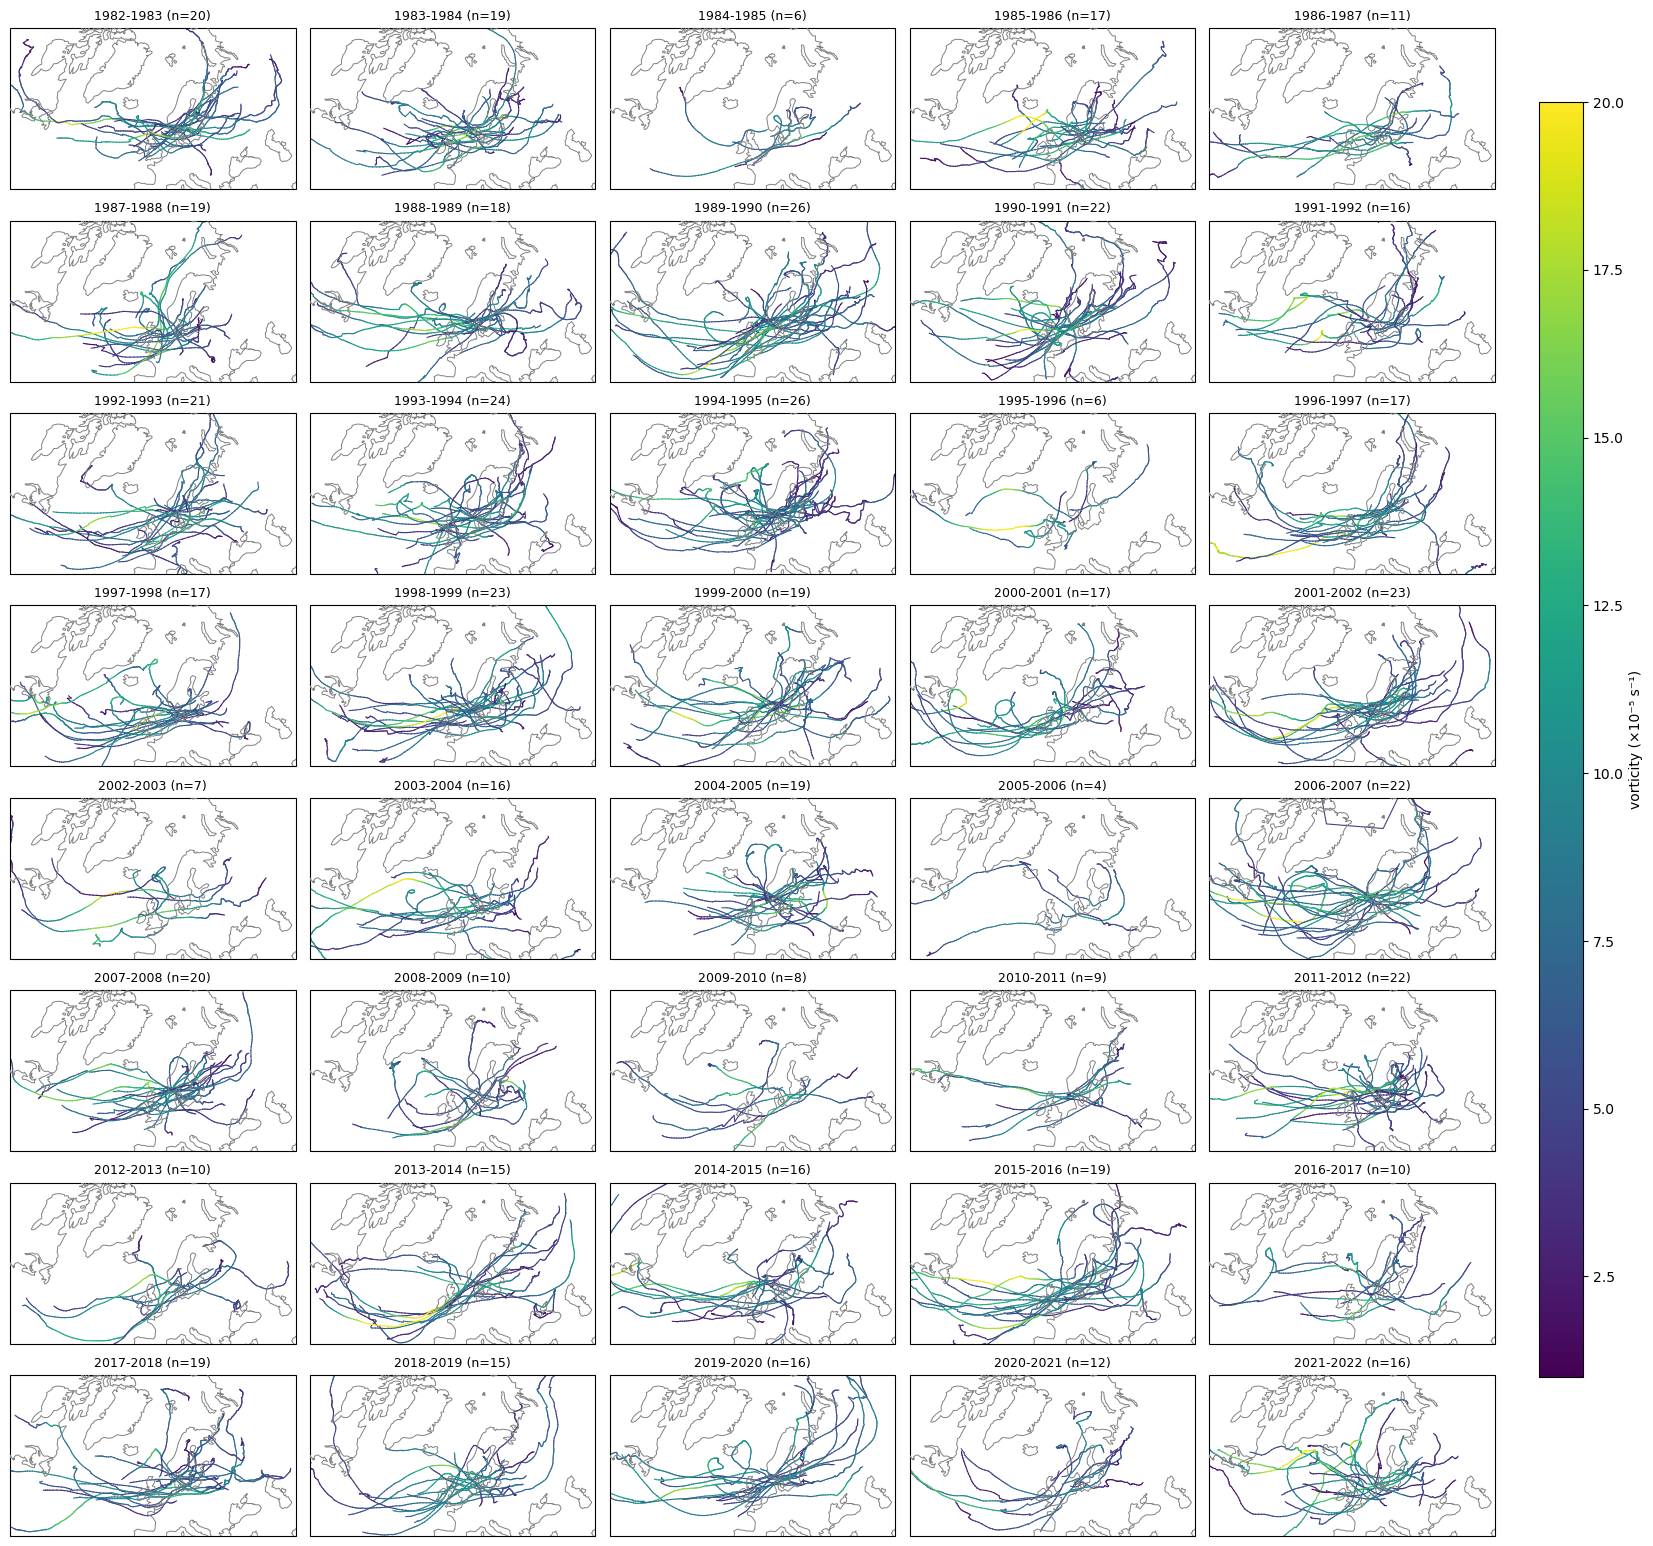

In [112]:
warnings.filterwarnings('ignore', category=pd.errors.SettingWithCopyWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

datacrs = ccrs.PlateCarree()
mapcrs = ccrs.Orthographic(central_longitude=0, central_latitude=50)
boundary = [-70, 60, 90, 40]

fig, axs = plt.subplots(8, 5, sharey=True, sharex=True, figsize=(22., 17.), subplot_kw={'projection': mapcrs})
axs = axs.ravel()

for iyear, ax in enumerate(axs):
    year = 1982 + iyear
    trx_season = trx_all[trx_all['season'] == f'{year}-{year+1}']
    if trx_season.empty:
        continue

    season = trx_season['season'].iloc[0]
    n_storm = trx_season['ID'].nunique()

    ax.set_extent(boundary, crs=datacrs)
    #ax.add_feature(cartopy.feature.COASTLINE, zorder=17)
    ax.coastlines(resolution='110m', zorder=17, linewidth=0.7, color='grey')

    cmap = plt.cm.viridis
    norm = Normalize(1, 20)

    points = trx_season[['lon_vor', 'lat_vor']].values
    color_values = norm(trx_season['var_vor'].values)
    colors = cmap(color_values)

    for idx, group in trx_season.groupby('ID'):
        points = group[['lon_vor', 'lat_vor']].values
        for i in range(len(points) - 1):
            line = np.array([points[i], points[i + 1]])
            mid_value = norm((group['var_vor'].iloc[i] + group['var_vor'].iloc[i + 1]) / 2)
            ax.plot(line[:, 0], line[:, 1], color=cmap(mid_value),
                    linewidth=0.8, transform=datacrs)

    ax.set_title(f'{season} (n={n_storm})', fontsize=9)

fig.subplots_adjust(bottom=0.05, right=0.8, top=0.95, wspace=0.05, hspace=0.05)
cax = fig.add_axes([0.82, 0.15, 0.02, 0.75])
#labelin = 'Track translation speed (km/h)'
labelin = 'vorticity (×10⁻⁵ s⁻¹)'
plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), cax=cax, pad=0.05, aspect=50, orientation='vertical', label=labelin)

plt.show()

### Season Storminess Index
![image.png](https://i.postimg.cc/QxBg6SmY/Screenshot-2024-08-31-at-8-36-37-am.png)

In [276]:
storm_north = trx_all[(trx_all['lat_vor'] >= 50) & (trx_all['lat_vor'] <= 60) &
                 (trx_all['lon_vor'] >= -10) & (trx_all['lon_vor'] <= 10)]

vor_perc = storm_north.groupby('season')['var_mslp'].apply(lambda x: x.quantile(0.98))
vor_mean = storm_north['var_mslp'].mean()
vor_std = storm_north['var_mslp'].std()
#print('mean:', vor_mean, 'std:', vor_std)

ssi = (vor_perc.values - vor_mean) / vor_std
#ssi = vor_perc

In [252]:
vor_perc = trx_all.groupby('season')['var_mslp'].apply(lambda x: x.quantile(0.9))
vor_mean = trx_all['var_mslp'].mean()
vor_std = trx_all['var_mslp'].std()
#print('mean:', vor_mean, 'std:', vor_std)

ssi = (vor_perc.values - vor_mean) / vor_std
#ssi = vor_perc

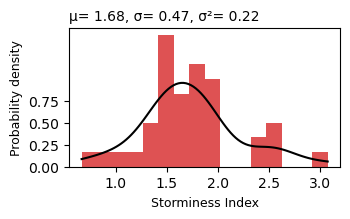

In [277]:
kde_ssi = gaussian_kde(ssi)
x_ssi = np.linspace(min(ssi), max(ssi), 100)
kde_values_ssi = kde_ssi(x_ssi)

mean_ssi = np.sum(x_ssi * kde_values_ssi) * (x_ssi[1] - x_ssi[0])
variance_ssi = np.sum((x_ssi - mean_ssi)**2 * kde_values_ssi) * (x_ssi[1] - x_ssi[0])
std_ssi = np.sqrt(variance_ssi)

# Plot the results
fig, axs = plt.subplots(1, 1, figsize=(3.6, 2.3))
#axs.set_xlim(0,30)
axs.set_yticks(np.arange(0,1,0.25))
axs.hist(ssi, bins=16, density=True, alpha=0.8, color='tab:red')
axs.plot(x_ssi, kde_values_ssi, label='KDE', color='black')
axs.set_title(f'μ= {mean_ssi:.2f}, σ= {std_ssi:.2f}, σ²= {variance_ssi:.2f}', fontsize=10, loc='left')
axs.set_xlabel('Storminess Index', fontsize=9)
axs.set_ylabel('Probability density', fontsize=9)
plt.tight_layout()
plt.show()

In [279]:
from scipy.stats import linregress

range_season = np.arange(0,40,1)
slope, intercept, r_value, p_value, std_err = linregress(range_season, ssi)
Y_pred = intercept + slope * range_season

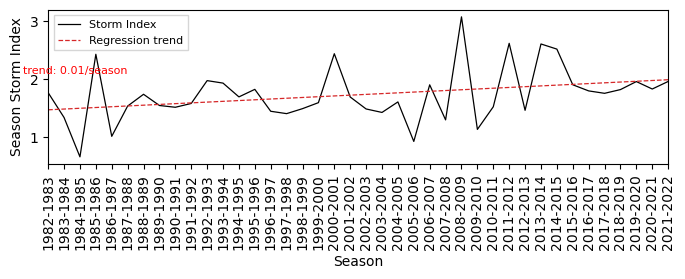

In [280]:
fig, ax = plt.subplots(figsize=(8., 2.))
#ax.set_ylim(-2.5,2.5)
ax.plot(season_list, ssi, color='black', linewidth=0.9, label='Storm Index')
ax.plot(season_list, Y_pred, color='tab:red', linewidth=0.9, linestyle='--', label='Regression trend')
ax.legend(fontsize=8, fancybox=False)
ax.set_ylabel('Season Storm Index')
ax.set_xlabel('Season')
ax.set_xlim(0,39)
slope_text = f'trend: {slope:.2f}/season'
plt.text(-1.6, 2.1, slope_text, fontsize=8, color='red')
plt.setp(ax.get_xticklabels(), rotation=90, ha='center')
plt.show()

In [75]:
filtered_storm = trx_all.drop_duplicates(subset=['ID'])
season_counts = filtered_storm['season'].value_counts().sort_index()
season_list = season_counts.index.to_list()

In [17]:
freq_trx = trx_all.drop_duplicates(subset=['uniq_id'])
year_freq_trx = freq_trx['season'].value_counts().sort_index()
year_freq_trx = year_freq_trx.values.tolist()

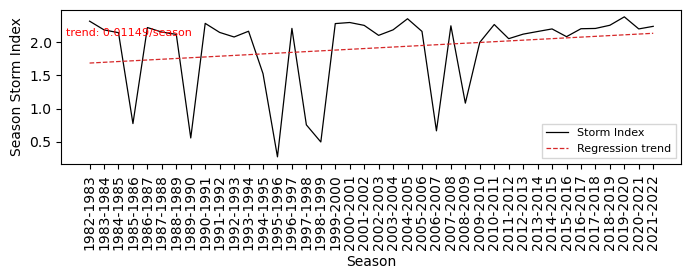

In [170]:
vor_perc_wind = trx_all.groupby('season')['speed'].apply(lambda x: x.quantile(0.97))
vor_mean_wind = trx_all.groupby('season')['speed'].mean()
vor_std_wind = trx_all.groupby('season')['speed'].std()
ssi_wind = (vor_perc_wind.values - vor_mean_wind.values) / vor_std_wind.values

slope_w, intercept_w, r_value_w, p_value_w, std_err_w = linregress(range_season, ssi_wind)
Y_pred_wind = intercept_w + slope_w * range_season

fig, ax = plt.subplots(figsize=(8., 2.))
#ax.set_ylim(-2.5,2.5)
ax.plot(season_list, ssi_wind, color='black', linewidth=0.9, label='Storm Index')
ax.plot(range_season, Y_pred_wind, color='tab:red', linewidth=0.9, linestyle='--', label='Regression trend')
ax.legend(fontsize=8, fancybox=False)
ax.set_ylabel('Season Storm Index')
ax.set_xlabel('Season')
slope_text = f'trend: {slope_w:.5f}/season'
plt.text(-1.6, 2.1, slope_text, fontsize=8, color='red')
plt.setp(ax.get_xticklabels(), rotation=90, ha='center')
plt.show()

### Identifying Storms Track Direction

In [140]:
def storm_direction(group):
    westerly_count = sum((group['bearing'] >= 30) & (group['bearing'] <= 120))
    northerly_count = sum((group['bearing'] > 120) & (group['bearing'] <= 240))
    if northerly_count > westerly_count:
        return 'Northerly'
    else:
        return 'Westerly'

In [141]:
storm_filter = trx_all[(trx_all['lat_vor'] >= 50) & (trx_all['lat_vor'] <= 60) &
                 (trx_all['lon_vor'] >= -10) & (trx_all['lon_vor'] <= 10)]

category = storm_filter.groupby('uniq_id').apply(storm_direction).reset_index()
category.columns = ['uniq_id', 'category']

trx_all = trx_all.merge(category, on='uniq_id', how='left')
trx_all.head()

/tmp/ipykernel_555/1467547435.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  category = storm_filter.groupby('uniq_id').apply(storm_direction).reset_index()


,Unnamed: 0,date,lon_vor,lat_vor,var_vor,lon_mslp,lat_mslp,var_mslp,lon_wind,lat_wind,...,start_time,median_time,name,season,duration,distance,speed,bearing,uniq_id,category
0,0,1982-10-19 13:00:00,1.534199,58.076061,2.661184,NaN,NaN,1003.516,4.21875,62.52924,...,1982-10-19 13:00:00,NaN,NaN,1982-1983,5 days 15:00:00,88.879012,24.688614,133.170995,"(2641, 1982-1983)",Westerly
1,1,1982-10-19 14:00:00,2.616141,57.525417,2.881066,NaN,NaN,1005.743,4.78125,62.24821,...,1982-10-19 13:00:00,NaN,NaN,1982-1983,5 days 15:00:00,49.974489,13.881802,107.550211,"(2641, 1982-1983)",Westerly
2,2,1982-10-19 15:00:00,3.408462,57.387611,3.076569,NaN,NaN,1006.686,4.78125,62.52924,...,1982-10-19 13:00:00,NaN,NaN,1982-1983,5 days 15:00:00,31.974425,8.881785,79.587082,"(2641, 1982-1983)",Westerly
3,3,1982-10-19 16:00:00,3.932111,57.438416,3.175046,NaN,NaN,1006.377,5.06250,62.52924,...,1982-10-19 13:00:00,NaN,NaN,1982-1983,5 days 15:00:00,35.852547,9.959041,52.889083,"(2641, 1982-1983)",Westerly
4,4,1982-10-19 17:00:00,4.410720,57.631748,3.225164,NaN,NaN,1005.896,5.34375,62.81027,...,1982-10-19 13:00:00,NaN,NaN,1982-1983,5 days 15:00:00,55.710140,15.475039,45.840539,"(2641, 1982-1983)",Westerly


In [142]:
merged_data = trx_all.drop_duplicates(subset=['uniq_id'])
season_counts_bar = merged_data.groupby(['season', 'category']).size().unstack(fill_value=0)

colors = [color_mapping.get(col, 'tab:gray') for col in season_counts_bar.columns]
season_counts_bar.plot(kind='bar', stacked=True, ax=ax1, width=0.8, color=colors, legend=False)

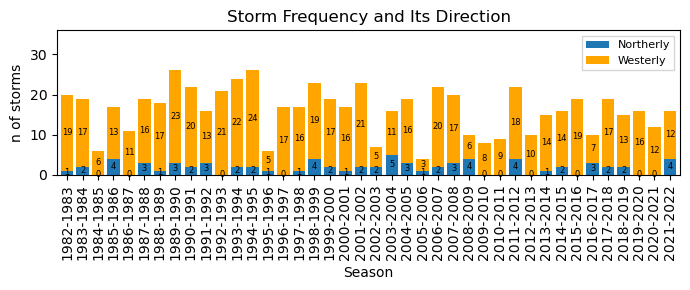

In [12]:
fig, ax = plt.subplots(figsize=(7., 3.))
color_mapping = {
    'Northerly': 'tab:blue',
    'Westerly': 'orange'
}

colors = [color_mapping.get(col, 'tab:gray') for col in season_counts.columns]
season_counts.plot(kind='bar', stacked=True, ax=ax, width=0.8, color=colors)

ax.set_title('Storm Frequency and Its Direction')
ax.set_xlabel('Season')
ax.set_ylabel('n of storms')
ax.set_ylim(0, max(season_counts.sum(axis=1)) + 10)
plt.legend(fancybox=False, fontsize=8)

for container in ax.containers:
    ax.bar_label(container, label_type='center', fontsize=6)

plt.tight_layout()
plt.show()

[18.56219512 18.43592871 18.30966229 18.18339587 18.05712946 17.93086304
 17.80459662 17.67833021 17.55206379 17.42579737 17.29953096 17.17326454
 17.04699812 16.92073171 16.79446529 16.66819887 16.54193246 16.41566604
 16.28939962 16.16313321 16.03686679 15.91060038 15.78433396 15.65806754
 15.53180113 15.40553471 15.27926829 15.15300188 15.02673546 14.90046904
 14.77420263 14.64793621 14.52166979 14.39540338 14.26913696 14.14287054
 14.01660413 13.89033771 13.76407129 13.63780488]
[20 19  6 17 11 19 18 26 22 16 21 24 25  6 17 17 23 19 17 23  7 16 18  4
 22 19 10  8  9 22 10 15 15 19 10 17 15 16 11 15]


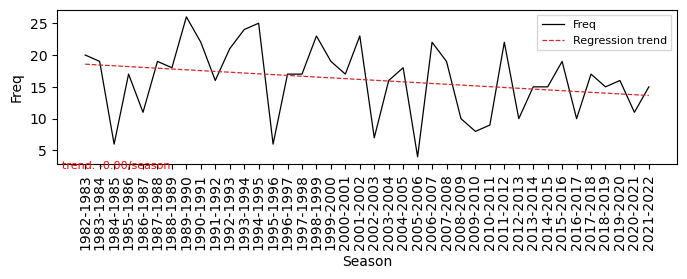

In [146]:
slope_f, intercept_f, r_value_f, p_value_f, std_err_f = linregress(range_season, season_counts.values)

Y_pred_freq = intercept_f + slope_f * range_season

fig, ax = plt.subplots(figsize=(8., 2.))
#ax.set_ylim(-2.5,2.5)
ax.plot(season_list, season_counts.values, color='black', linewidth=0.9, label='Freq')
ax.plot(range_season, Y_pred_freq, color='tab:red', linewidth=0.9, linestyle='--', label='Regression trend')
ax.legend(fontsize=8, fancybox=False)
ax.set_ylabel('Freq')
ax.set_xlabel('Season')
slope_text = f'trend: {slope:.2f}/season'
plt.text(-1.6, 2.1, slope_text, fontsize=8, color='red')
plt.setp(ax.get_xticklabels(), rotation=90, ha='center')
plt.show()

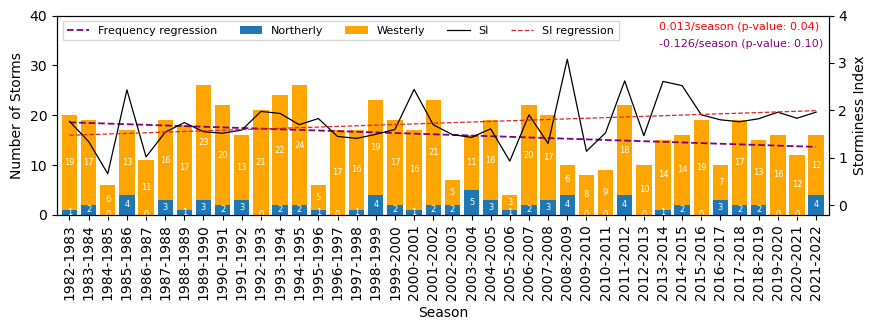

In [287]:
fig, ax1 = plt.subplots(figsize=(9., 3.4))
color_mapping = {
    'Northerly': 'tab:blue',
    'Westerly': 'orange'
}

colors = [color_mapping.get(col, 'tab:gray') for col in season_counts_bar.columns]
season_counts_bar.plot(kind='bar', stacked=True, ax=ax1, width=0.8, color=colors, legend=False)
ax1.plot(range_season, Y_pred_freq, color='purple', linewidth=1.3, linestyle='--', label='Frequency regression')
ax1.set_xlabel('Season')
ax1.set_ylabel('Number of Storms')
ax1.set_ylim(0, 40)
slope_freq = f'{slope_f:.3f}/season (p-value: {p_value_f:.2f})'
#ax1.legend(fancybox=False, fontsize=8)

for container in ax1.containers:
    ax1.bar_label(container, label_type='center', fontsize=6, color='white')

ax2 = ax1.twinx()
ax2.set_ylim(-0.2, 4)
ax2.plot(season_list, ssi, color='black', linewidth=0.9, label='SI')
ax2.plot(range_season, Y_pred, color='tab:red', linewidth=0.9, linestyle='--', label='SI regression')
ax2.set_ylabel('Storminess Index')

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, fontsize=8, fancybox=False, ncol=5, loc='upper left')
#ax2.legend(lines + lines2, labels + labels2, fontsize=8, fancybox=False, loc='upper left', bbox_to_anchor=(1.05, 1))

slope_ssi = f'{ slope:.3f}/season (p-value: {p_value:.2f})'
ax2.text(30.78, 3.33, slope_freq, fontsize=8, color='purple')
ax2.text(30.78, 3.7, slope_ssi, fontsize=8, color='red')

plt.setp(ax1.get_xticklabels(), rotation=90, ha='center')
plt.tight_layout()
plt.show()


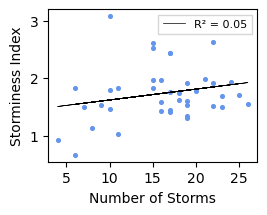

In [288]:
filtered_storm = trx_all.drop_duplicates(subset=['ID'])
season_counts = filtered_storm['season'].value_counts().sort_index()

slopew, interceptw, r_valuew, p_valuew, std_errw = linregress(season_counts, ssi)
line = slopew * season_counts + interceptw

plt.figure(figsize=(2.7, 1.98))
plt.scatter(season_counts, ssi, color='cornflowerblue', label='', s=7)
plt.plot(season_counts, line, color='black', linestyle='-', linewidth=0.5, label=f'R² = {r_valuew**2:.2f}')
plt.xlabel('Number of Storms')
plt.ylabel('Storminess Index')
#plt.xticks(np.arange(1,9,1))
#plt.ylim(1,3.1)
#plt.xlim(0.5,8.5)
plt.legend(fontsize=8, loc='best', fancybox=False)
plt.show()

/tmp/ipykernel_1071/1916784185.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_data['month'] = pd.to_datetime(merged_data['start_time']).dt.month


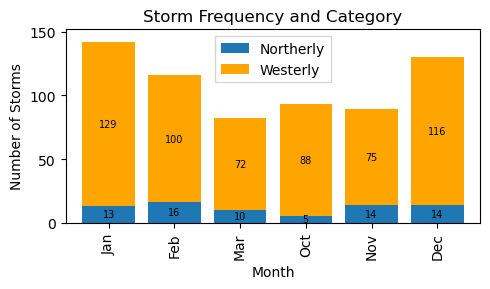

In [165]:
merged_data = trx_all.drop_duplicates(subset=['uniq_id'])
merged_data['month'] = pd.to_datetime(merged_data['start_time']).dt.month
monthly_counts = merged_data.groupby(['month', 'category']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(5., 3.))
color_mapping = {
    'Northerly': 'tab:blue',
    'Westerly': 'orange'
}

colors = [color_mapping.get(col, 'tab:gray') for col in monthly_counts.columns]
monthly_counts.plot(kind='bar', stacked=True, ax=ax, width=0.8, color=colors)

ax.set_title('Storm Frequency and Category')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Storms')
ax.set_ylim(0, max(monthly_counts.sum(axis=1)) + 10)
ax.set_xticks(range(6))
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Oct', 'Nov', 'Dec'])
plt.legend(fancybox=False)

for container in ax.containers:
    ax.bar_label(container, label_type='center', fontsize=7)

plt.tight_layout()
plt.show()


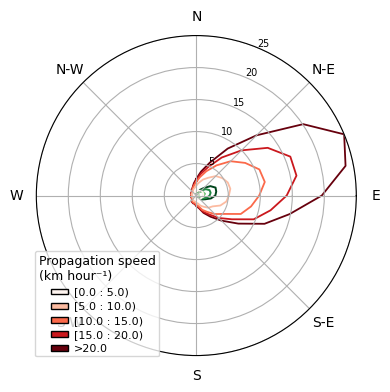

In [10]:
from windrose import WindroseAxes
import matplotlib.cm as cm
trx_dir_all = trx_all.dropna(subset=['bearing', 'speed'])
northsea_bound = trx_dir_all[(trx_dir_all['lon_vor'] >= -4) & (trx_dir_all['lon_vor'] <= 10) & 
                      (trx_dir_all['lat_vor'] >= 50) & (trx_dir_all['lat_vor'] <= 60)]
trx_dir_north = northsea_bound.dropna(subset=['bearing', 'speed'])

fig = plt.figure(figsize=(4., 4.))
ax = WindroseAxes.from_ax(fig=fig)

#ax.contourf(trx_dir_all['bearing'].values, trx_dir_all['speed'].values, bins=np.arange(0, 40, 10), cmap=plt.cm.Blues, alpha=0.9, normed=True)
ax.contour(trx_dir_all['bearing'].values, trx_dir_all['speed'].values, bins=np.arange(0, 22, 5), cmap=cm.Reds, 
           lw=1.3, alpha=1, nsector=32) #normed=True, 
ax.contour(trx_dir_north['bearing'].values, trx_dir_north['speed'].values, bins=np.arange(0, 22, 5), cmap=cm.Greens, 
           lw=1.4, alpha=1, nsector=32) #normed=True,


#ax.contourf(trx_dir_north['bearing'].values, trx_dir_north['speed'].values, bins=np.arange(0, 40, 10), cmap=plt.cm.Reds, alpha=0.4, normed=True)

#ax.set_rgrids([], labels=None)
ax.set_yticklabels([5, 10, 15, 20, 25], fontsize=7)
ax.set_legend(title="Propagation speed\n(km hour⁻¹)", title_fontsize=9, loc="lower left", fontsize=6)
plt.show()

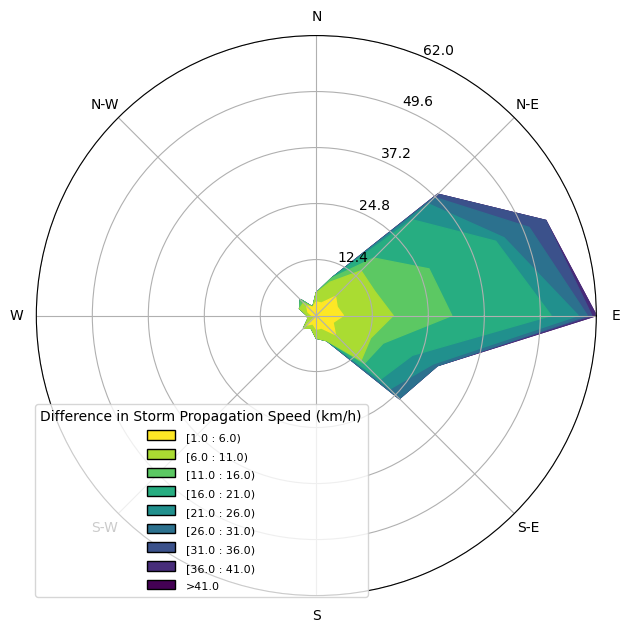

In [170]:
def bin_wind_data(directions, speeds, direction_bins=36, speed_bins=9, speed_range=(0, 45)):
    direction_bins = np.linspace(0, 360, direction_bins + 1)
    speed_bins = np.linspace(speed_range[0], speed_range[1], speed_bins + 1)
    
    binned_data = pd.DataFrame(index=pd.IntervalIndex.from_breaks(direction_bins, closed='left'),
                               columns=pd.IntervalIndex.from_breaks(speed_bins, closed='left'))
    binned_data[:] = 0
    
    for d, s in zip(directions, speeds):
        dir_bin = np.digitize(d, direction_bins) - 1
        spd_bin = np.digitize(s, speed_bins) - 1
        if dir_bin < len(direction_bins) - 1 and spd_bin < len(speed_bins) - 1:
            binned_data.iloc[dir_bin, spd_bin] += 1
    
    binned_data /= len(directions)
    
    return binned_data

binned_all = bin_wind_data(trx_dir_all['bearing'].values, trx_dir_all['speed'].values)
binned_north = bin_wind_data(trx_dir_north['bearing'].values, trx_dir_north['speed'].values)

binned_diff = binned_all - binned_north

synthetic_directions = []
synthetic_speeds = []

for i, dir_bin in enumerate(binned_diff.index):
    for j, spd_bin in enumerate(binned_diff.columns):
        value = binned_diff.iloc[i, j]
        if value != 0:
            count = int(abs(value * 1000)) 
            synthetic_directions.extend([dir_bin.left + (dir_bin.right - dir_bin.left) / 2] * count)
            synthetic_speeds.extend([spd_bin.left + (spd_bin.right - spd_bin.left) / 2] * count)

synthetic_directions = np.array(synthetic_directions)
synthetic_speeds = np.array(synthetic_speeds)


fig = plt.figure(figsize=(7, 7.))
ax = WindroseAxes.from_ax(fig=fig)
ax.contourf(synthetic_directions, synthetic_speeds, bins=np.arange(1, 45, 5), cmap=plt.cm.viridis_r)
ax.set_legend(title="Difference in Storm Propagation Speed (km/h)", loc="lower left")

plt.show()

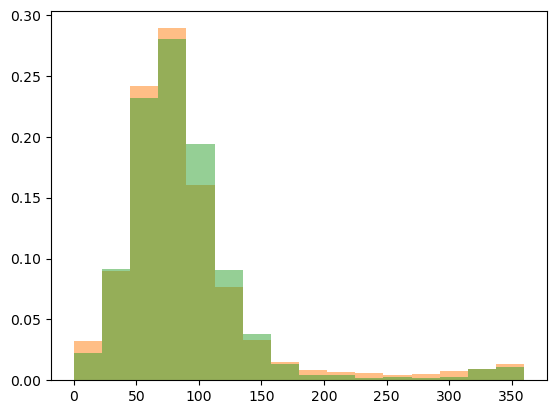

In [8]:
ax = WindroseAxes.from_ax(fig=fig)

bear_north = trx_dir_north['bearing'].values
speeds_north = trx_dir_north['speed'].values
norm_speeds_north = speeds_north / np.sum(speeds_north)

bear_all = trx_dir_all['bearing'].values
speeds_all = trx_dir_all['speed'].values
norm_speeds_all = speeds_all / np.sum(speeds_all)

nsector = 16
sectors = np.linspace(0, 360, nsector + 1)

table = ax._info['table']
wd_freq = np.sum(table, axis=0)


fig, ax2 = plt.subplots()
ax2.bar(np.arange(nsector), wd_freq, align='center')
histno, edgesno = np.histogram(bear_north, bins=sectors, weights=norm_speeds_north)
hist, edges = np.histogram(bear_all, bins=sectors, weights=norm_speeds_all)

ax2.bar(edges[:-1], hist, width=np.diff(edges), align='edge', alpha=0.5, label='All')
ax2.bar(edgesno[:-1], histno, width=np.diff(edgesno), align='edge', alpha=0.5, label='North')

plt.show()


### Identifying Storms Tides Time

In [113]:
moon_cal = pd.read_csv('moon_phase_calendar.csv')
trx_all['date'] = pd.to_datetime(trx_all['date'])
moon_cal['Start'] = pd.to_datetime(moon_cal['Start'], format='%d/%m/%Y %H:%M:%S')
moon_cal['End'] = pd.to_datetime(moon_cal['End'], format='%d/%m/%Y %H:%M:%S')
trx_all['Tide'] = pd.NA

,Moon Phase,Datetime,Start,End,Tide
0,Full Moon,03/10/1982 01:09:00,30/09/1982 01:09:00,06/10/1982 01:09:00,Spring
1,Last Quarter,09/10/1982 23:26:00,NaN,NaN,Neap
2,New Moon,17/10/1982 00:04:00,14/10/1982 00:04:00,20/10/1982 00:04:00,Spring
3,First Quarter,25/10/1982 00:08:00,NaN,NaN,Neap
4,Full Moon,01/11/1982 12:57:00,29/10/1982 12:57:00,04/11/1982 12:57:00,Spring
...,...,...,...,...,...
982,Last Quarter,23/02/2022 22:32:00,NaN,NaN,Neap
983,New Moon,02/03/2022 17:35:00,27/02/2022 17:35:00,05/03/2022 17:35:00,Spring
984,First Quarter,10/03/2022 10:45:00,NaN,NaN,Neap
985,Full Moon,18/03/2022 07:17:00,15/03/2022 07:17:00,21/03/2022 07:17:00,Spring


In [114]:
for _, row in moon_cal.iterrows():
    start_date = pd.to_datetime(row['Start'])
    end_date = pd.to_datetime(row['End'])
    spring = row['Tide']

    northsea_bound = trx_all[(trx_all['lon_vor'] >= -12) & (trx_all['lon_vor'] <= 12) & 
                             (trx_all['lat_vor'] >= 45) & (trx_all['lat_vor'] <= 65)]
    
    valid_ids = northsea_bound[(northsea_bound['date'] >= start_date) & 
                               (northsea_bound['date'] <= end_date)][['uniq_id']].drop_duplicates()

    trx_all.loc[trx_all['uniq_id'].isin(valid_ids['uniq_id']), 'Tide'] = spring

trx_all['Tide'].fillna('Neap', inplace=True)
trx_all.head()

,Unnamed: 0,date,lon_vor,lat_vor,var_vor,lon_mslp,lat_mslp,var_mslp,lon_wind,lat_wind,...,start_time,median_time,name,season,duration,distance,speed,bearing,uniq_id,Tide
0,0,1982-10-19 13:00:00,1.534199,58.076061,2.661184,NaN,NaN,1003.516,4.21875,62.52924,...,1982-10-19 13:00:00,NaN,NaN,1982-1983,5 days 15:00:00,88.879012,24.688614,133.170995,"(2641, 1982-1983)",Spring
1,1,1982-10-19 14:00:00,2.616141,57.525417,2.881066,NaN,NaN,1005.743,4.78125,62.24821,...,1982-10-19 13:00:00,NaN,NaN,1982-1983,5 days 15:00:00,49.974489,13.881802,107.550211,"(2641, 1982-1983)",Spring
2,2,1982-10-19 15:00:00,3.408462,57.387611,3.076569,NaN,NaN,1006.686,4.78125,62.52924,...,1982-10-19 13:00:00,NaN,NaN,1982-1983,5 days 15:00:00,31.974425,8.881785,79.587082,"(2641, 1982-1983)",Spring
3,3,1982-10-19 16:00:00,3.932111,57.438416,3.175046,NaN,NaN,1006.377,5.06250,62.52924,...,1982-10-19 13:00:00,NaN,NaN,1982-1983,5 days 15:00:00,35.852547,9.959041,52.889083,"(2641, 1982-1983)",Spring
4,4,1982-10-19 17:00:00,4.410720,57.631748,3.225164,NaN,NaN,1005.896,5.34375,62.81027,...,1982-10-19 13:00:00,NaN,NaN,1982-1983,5 days 15:00:00,55.710140,15.475039,45.840539,"(2641, 1982-1983)",Spring


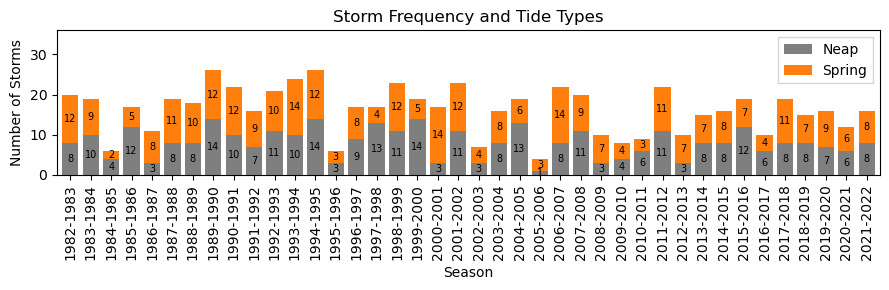

In [256]:
merged_data = trx_all.drop_duplicates(subset=['uniq_id'])
tide_counts = merged_data.groupby(['season', 'Tide']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(9., 3.))
color_mapping = {
    'Spring': 'tab:orange',
    'neap': 'tab:blue'
}

colors = [color_mapping.get(col, 'tab:gray') for col in tide_counts.columns]
tide_counts.plot(kind='bar', stacked=True, ax=ax, width=0.8, color=colors)

ax.set_title('Storm Frequency and Tide Types')
ax.set_xlabel('Season')
ax.set_ylabel('Number of Storms')
ax.set_ylim(0, max(tide_counts.sum(axis=1)) + 10)
plt.legend(fancybox=False)

for container in ax.containers:
    ax.bar_label(container, label_type='center', fontsize=7)

plt.tight_layout()
plt.show()

In [243]:
seldata = trx_all.drop_duplicates(subset=['uniq_id'])
#spring_westerly = seldata[(seldata['Tide'] == 'Spring') & (seldata['category'] == 'Westerly')]
#spring_northerly = seldata[(seldata['Tide'] == 'Spring') & (seldata['category'] == 'Northerly')]
#neap_westerly = seldata[(seldata['Tide'] == 'Neap') & (seldata['category'] == 'Westerly')]
#neap_northerly = seldata[(seldata['Tide'] == 'Neap') & (seldata['category'] == 'Northerly')]

def categorize_row(row):
    if row['Tide'] == 'Spring' and row['category'] == 'Westerly':
        return 'spring_westerly'
    elif row['Tide'] == 'Spring' and row['category'] == 'Northerly':
        return 'spring_northerly'
    elif row['Tide'] == 'Neap' and row['category'] == 'Westerly':
        return 'neap_westerly'
    elif row['Tide'] == 'Neap' and row['category'] == 'Northerly':
        return 'neap_northerly'
    else:
        return 'other'

seldata['category_combination'] = seldata.apply(categorize_row, axis=1)
seldata.head()

,Unnamed: 0,date,lon_vor,lat_vor,var_vor,lon_mslp,lat_mslp,var_mslp,lon_wind,lat_wind,...,name,season,duration,distance,speed,bearing,uniq_id,Tide,category,category_combination
0,0,1982-10-19 13:00:00,1.534199,58.076061,2.661184,NaN,NaN,1003.5160,4.21875,62.52924,...,NaN,1982-1983,5 days 15:00:00,88.879012,24.688614,133.170995,"(2641, 1982-1983)",Spring,Westerly,spring_westerly
136,136,1982-11-10 21:00:00,2.573082,57.162121,3.364289,NaN,NaN,992.8041,3.65625,57.18967,...,NaN,1982-1983,2 days 04:00:00,165.119685,45.866579,52.836603,"(5706, 1982-1983)",Neap,Westerly,neap_westerly
189,189,1982-11-14 08:00:00,-93.130280,41.930607,6.182187,NaN,NaN,1019.2500,262.96880,40.60888,...,NaN,1982-1983,7 days 22:00:00,92.712692,25.753526,85.521610,"(6195, 1982-1983)",Neap,Westerly,neap_westerly
380,380,1982-11-22 07:00:00,-29.860596,53.163204,5.235609,NaN,NaN,996.0288,328.50000,48.19670,...,NaN,1982-1983,6 days 00:00:00,116.496237,32.360066,171.687698,"(7344, 1982-1983)",Neap,Westerly,neap_westerly
525,525,1982-12-09 09:00:00,-13.972504,53.655842,4.941949,NaN,NaN,979.3325,336.37500,55.78452,...,NaN,1982-1983,4 days 14:00:00,33.347488,9.263191,86.940691,"(9895, 1982-1983)",Neap,Westerly,neap_westerly


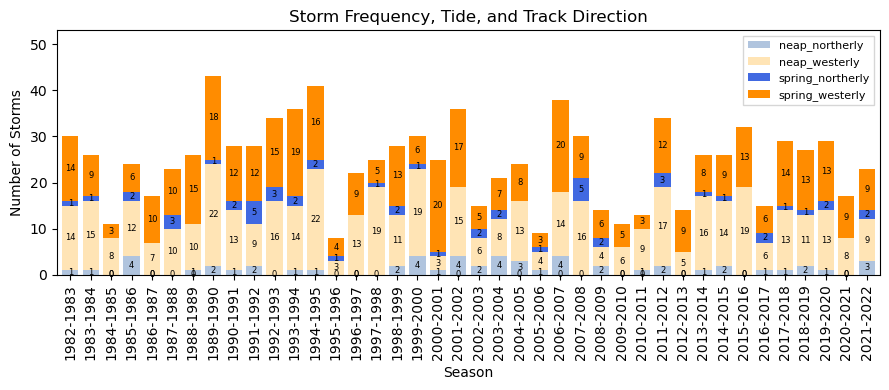

In [25]:
season_counts = seldata.groupby(['season', 'category_combination']).size().unstack(fill_value=0)

# Create the stacked bar plot
fig, ax = plt.subplots(figsize=(9., 4.))
color_mapping = {
    'spring_westerly': 'darkorange',
    'spring_northerly': 'royalblue',
    'neap_westerly': 'moccasin',
    'neap_northerly': 'lightsteelblue'
}

# Apply color mapping
colors = [color_mapping.get(col, 'tab:gray') for col in season_counts.columns]
season_counts.plot(kind='bar', stacked=True, ax=ax, width=0.8, color=colors)

# Set the title and labels
ax.set_title('Storm Frequency, Tide, and Track Direction')
ax.set_xlabel('Season')
ax.set_ylabel('Number of Storms')
ax.set_ylim(0, max(season_counts.sum(axis=1)) + 10)
plt.legend(fancybox=False, fontsize=8)

for container in ax.containers:
    ax.bar_label(container, label_type='center', fontsize=6)

plt.tight_layout()
plt.show()

### DJF North Sea Storm

In [43]:
trx_all['date'] = pd.to_datetime(trx_all['date'])
trx_all['month'] = trx_all['date'].dt.month
trx_all_djf = trx_all[trx_all['month'].isin([12, 1, 2])]

In [44]:
trx_all_dec00 = trx_all_djf[(trx_all_djf['season']=='2000-2001') & (trx_all_djf['month']==12)]
count_storm_dec00 = trx_all_dec00.drop_duplicates(subset=['uniq_id'])
count_storm_dec00['uniq_id'].nunique()

6